Project Details
Customer purchase prediction


## Data Preparation



In [6]:
from locale import normalize

import np
import pandas as pd

In [15]:
import numpy as np

df = pd.read_csv("data.csv")
df.replace("?", np.nan, inplace = True)

,ORDER_ID,CLASS,B_EMAIL,B_TELEFON,B_BIRTHDATE,FLAG_LRIDENTISCH,FLAG_NEWSLETTER,Z_METHODE,Z_CARD_ART,Z_CARD_VALID,...,FAIL_RPLZ,FAIL_RORT,FAIL_RPLZORTMATCH,SESSION_TIME,NEUKUNDE,AMOUNT_ORDER_PRE,VALUE_ORDER_PRE,DATE_LORDER,MAHN_AKT,MAHN_HOECHST
0,49917,no,yes,no,1/17/1973,yes,yes,check,NaN,5.2006,...,no,no,no,8,yes,0,0.00,NaN,NaN,NaN
1,49919,no,yes,yes,12/8/1970,no,no,credit_card,Visa,12.2007,...,yes,no,no,13,yes,0,0.00,NaN,NaN,NaN
2,49923,no,yes,no,4/3/1972,yes,no,check,NaN,12.2007,...,no,no,no,3,yes,0,0.00,NaN,NaN,NaN
3,49924,no,no,yes,8/1/1966,yes,no,check,NaN,1.2007,...,no,no,no,11,no,4,75.72,5/12/2002,0,0
4,49927,no,yes,yes,12/21/1969,yes,no,credit_card,Eurocard,12.2006,...,no,no,no,16,yes,0,0.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,49821,no,yes,no,3/3/1981,yes,no,check,NaN,6.2005,...,no,no,no,10,no,1,40.83,3/9/2002,0,3
29996,49824,no,yes,no,2/21/1972,no,no,credit_card,Eurocard,5.2005,...,no,no,no,10,no,2,52.84,6/3/2001,0,0
29997,49825,no,yes,no,6/11/1980,no,no,credit_card,Eurocard,11.2006,...,no,no,no,6,yes,0,0.00,NaN,NaN,NaN
29998,49828,no,yes,no,12/4/1980,no,no,credit_card,Visa,4.2005,...,no,no,no,6,no,1,42.92,7/1/2001,0,0


In [16]:
print(df.shape)


(30000, 44)


In [17]:
print(df.head())

   ORDER_ID CLASS B_EMAIL B_TELEFON B_BIRTHDATE FLAG_LRIDENTISCH  \
0     49917    no     yes        no   1/17/1973              yes   
1     49919    no     yes       yes   12/8/1970               no   
2     49923    no     yes        no    4/3/1972              yes   
3     49924    no      no       yes    8/1/1966              yes   
4     49927    no     yes       yes  12/21/1969              yes   

  FLAG_NEWSLETTER    Z_METHODE Z_CARD_ART  Z_CARD_VALID  ... FAIL_RPLZ  \
0             yes        check        NaN        5.2006  ...        no   
1              no  credit_card       Visa       12.2007  ...       yes   
2              no        check        NaN       12.2007  ...        no   
3              no        check        NaN        1.2007  ...        no   
4              no  credit_card   Eurocard       12.2006  ...        no   

   FAIL_RORT FAIL_RPLZORTMATCH SESSION_TIME  NEUKUNDE  AMOUNT_ORDER_PRE  \
0         no                no            8       yes                 0

In [18]:
print(df.dtypes)

ORDER_ID               int64
CLASS                    str
B_EMAIL                  str
B_TELEFON                str
B_BIRTHDATE              str
FLAG_LRIDENTISCH         str
FLAG_NEWSLETTER          str
Z_METHODE                str
Z_CARD_ART               str
Z_CARD_VALID         float64
Z_LAST_NAME              str
VALUE_ORDER          float64
WEEKDAY_ORDER            str
TIME_ORDER               str
AMOUNT_ORDER           int64
ANUMMER_01             int64
ANUMMER_02               str
ANUMMER_03               str
ANUMMER_04               str
ANUMMER_05               str
ANUMMER_06               str
ANUMMER_07               str
ANUMMER_08               str
ANUMMER_09               str
ANUMMER_10               str
CHK_LADR                 str
CHK_RADR                 str
CHK_KTO                  str
CHK_CARD                 str
CHK_COOKIE               str
CHK_IP                   str
FAIL_LPLZ                str
FAIL_LORT                str
FAIL_LPLZORTMATCH        str
FAIL_RPLZ     

In [19]:
print(df.isnull().sum())

ORDER_ID                 0
CLASS                    0
B_EMAIL                  0
B_TELEFON                0
B_BIRTHDATE           2942
FLAG_LRIDENTISCH         0
FLAG_NEWSLETTER          0
Z_METHODE                0
Z_CARD_ART           18654
Z_CARD_VALID             0
Z_LAST_NAME          14808
VALUE_ORDER              0
WEEKDAY_ORDER            0
TIME_ORDER              20
AMOUNT_ORDER             0
ANUMMER_01               0
ANUMMER_02           22147
ANUMMER_03           26802
ANUMMER_04           28668
ANUMMER_05           29459
ANUMMER_06           29794
ANUMMER_07           29905
ANUMMER_08           29966
ANUMMER_09           29993
ANUMMER_10           30000
CHK_LADR                 0
CHK_RADR                 0
CHK_KTO                  0
CHK_CARD                 0
CHK_COOKIE               0
CHK_IP                   0
FAIL_LPLZ                0
FAIL_LORT                0
FAIL_LPLZORTMATCH        0
FAIL_RPLZ                0
FAIL_RORT                0
FAIL_RPLZORTMATCH        0
S

In [20]:
print(df.describe())

           ORDER_ID  Z_CARD_VALID   VALUE_ORDER  AMOUNT_ORDER     ANUMMER_01  \
count  30000.000000  30000.000000  30000.000000  30000.000000   30000.000000   
mean   25032.612933      6.680567     43.968058      1.442200  331860.254033   
std    14422.306098      3.468332     35.709431      0.921496  147310.846584   
min        1.000000      1.200500      5.200000      1.000000  100061.000000   
25%    12518.750000      3.200700     17.990000      1.000000  204159.000000   
50%    25095.500000      6.200700     34.500000      1.000000  401241.000000   
75%    37520.250000     10.200500     57.800000      2.000000  407703.000000   
max    50000.000000     12.200700    361.200000      9.000000  609725.000000   

       SESSION_TIME  AMOUNT_ORDER_PRE  VALUE_ORDER_PRE  
count  30000.000000      30000.000000     30000.000000  
mean       8.577900          0.606700        29.875652  
std        3.863448          0.765616        57.382732  
min        1.000000          0.000000         0.000

In [21]:
print(f'Duplicate Rows: {df.duplicated().sum()}')

Duplicate Rows: 0


## Drop columns

In [39]:
df2 = df.drop('ORDER_ID', axis = 1)
print(df2.isnull().sum())

CLASS                    0
B_EMAIL                  0
B_TELEFON                0
B_BIRTHDATE           2942
FLAG_LRIDENTISCH         0
FLAG_NEWSLETTER          0
Z_METHODE                0
Z_CARD_ART           18654
Z_CARD_VALID             0
Z_LAST_NAME          14808
VALUE_ORDER              0
WEEKDAY_ORDER            0
TIME_ORDER              20
AMOUNT_ORDER             0
ANUMMER_01               0
ANUMMER_02           22147
ANUMMER_03           26802
ANUMMER_04           28668
ANUMMER_05           29459
ANUMMER_06           29794
ANUMMER_07           29905
ANUMMER_08           29966
ANUMMER_09           29993
ANUMMER_10           30000
CHK_LADR                 0
CHK_RADR                 0
CHK_KTO                  0
CHK_CARD                 0
CHK_COOKIE               0
CHK_IP                   0
FAIL_LPLZ                0
FAIL_LORT                0
FAIL_LPLZORTMATCH        0
FAIL_RPLZ                0
FAIL_RORT                0
FAIL_RPLZORTMATCH        0
SESSION_TIME             0
N

In [38]:
df2['CLASS'].value_counts(normalize = True).mul(100).round(2).astype(str) + '%'

CLASS
no     94.18%
yes     5.82%
Name: proportion, dtype: str

In [35]:
(pd.crosstab(df2['B_EMAIL'], df2['CLASS'], normalize='index')
 .mul(100)
 .round(2)
 .astype(str) + '%')

CLASS,no,yes
B_EMAIL,,
no,90.18%,9.82%
yes,95.19%,4.81%


In [44]:
phone_risk_rate = df2.groupby("B_TELEFON")['CLASS'].value_counts(normalize=True).unstack()["yes"].mul(100).round(2).astype(str) + '%'
print(phone_risk_rate)

B_TELEFON
no      6.3%
yes    3.13%
Name: yes, dtype: str


In [47]:
risk_missing_birth = (
    df2.groupby(df2["B_BIRTHDATE"].isna())["CLASS"]
       .value_counts(normalize=True)
       .unstack()["yes"]
       .mul(100)
       .round(2)
       .astype(str) + '%'
)

print(risk_missing_birth)


B_BIRTHDATE
False     5.8%
True     6.02%
Name: yes, dtype: str


In [49]:
df2["B_BIRTHDATE"] = pd.to_datetime(df2["B_BIRTHDATE"])
df2["B_BIRTHDATE"].head()

0   1973-01-17
1   1970-12-08
2   1972-04-03
3   1966-08-01
4   1969-12-21
Name: B_BIRTHDATE, dtype: datetime64[us]

In [64]:
df2["AGE"] = 2007 - df2["B_BIRTHDATE"].dt.year

In [65]:
df2["AGE"].describe()

count    27058.000000
mean        36.417215
std          9.633060
min         21.000000
25%         29.000000
50%         35.000000
75%         43.000000
max         73.000000
Name: AGE, dtype: float64

<Axes: >

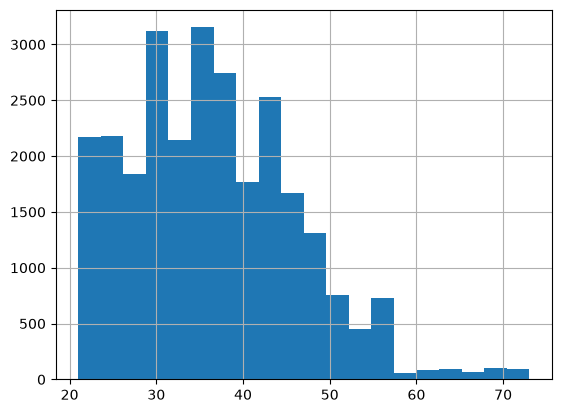

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
df2["AGE"].hist(bins=20)

In [67]:
df2["AGE_GROUP"] = pd.cut(
    df2["AGE"],
    bins=[0,18,30,45,60,100],
    labels=["<18","18-30","31-45","46-60","60+"]
)

In [68]:
df2["AGE_GROUP"] = (
    df2["AGE_GROUP"]
    .cat.add_categories("Missing")
    .fillna("Missing")
)

In [69]:
(
df2.groupby("AGE_GROUP")["CLASS"]
.value_counts(normalize=True)
.unstack()["yes"]
.mul(100)
.round(2)
)

AGE_GROUP
18-30      5.83
31-45      5.53
46-60      6.66
60+        5.64
Missing    6.02
Name: yes, dtype: float64

In [72]:
df2["AGE_GROUP"].value_counts(dropna=False)

AGE_GROUP
31-45      14172
18-30       8305
46-60       4173
Missing     2942
60+          408
<18            0
Name: count, dtype: int64

In [ ]:
df2 = df.drop("B_BIRTHDATE", axis = 1)